# Muestreo y datos desbalanceados

> Cómo muestrear y dividir los datos sin sesgos, y qué hacer cuando la clase que interesa es muy minoritaria: métricas adecuadas, remuestreo, pesos de clase y ajuste del umbral de decisión.
>
> **Requisitos previos:** [Análisis exploratorio](01-analisis-exploratorio.ipynb), [Transformación de datos](03-transformacion-datos.ipynb) · **Relacionado:** [Flujo de ML y evaluación](../04-machine-learning/01-flujo-ml-y-evaluacion.ipynb)

## 1. Idea clave

En muchos problemas reales la clase que interesa es rara: fraudes, averías, accidentes mortales, tumores. Un conjunto está **desbalanceado** (*imbalanced*) cuando una clase tiene muchas menos observaciones que las demás.

Esto causa dos problemas:

- **Evaluación engañosa**: un modelo que predice siempre la clase mayoritaria obtiene una exactitud altísima sin detectar un solo caso de la minoritaria.
- **Aprendizaje sesgado**: el modelo ve tan pocos ejemplos de la minoritaria que tiende a ignorarla.

Las soluciones actúan a tres niveles:
- en la **evaluación**: métricas por clase, particiones estratificadas;
- en los **datos**: sobremuestreo y submuestreo;
- en el **modelo**: pesos de clase y ajuste del umbral de decisión.

Antes de todo eso está el **muestreo**: elegir qué observaciones forman cada conjunto, de forma que representen bien a la población y a todas las clases.

## 2. Conceptos importantes

### 2.1. Técnicas de muestreo

Una **muestra** debe reproducir las propiedades de la población. Las técnicas **probabilísticas** permiten calcular la probabilidad de que cada elemento sea elegido:

| Técnica | Cómo se elige | Cuándo |
|---|---|---|
| **Aleatorio simple** | Todos los elementos tienen la misma probabilidad | Población homogénea |
| **Estratificado** | Se divide en grupos (estratos) y se muestrea cada uno en su proporción | Hay grupos importantes, sobre todo si alguno es pequeño |
| **Sistemático** | Uno de cada $N/n$ elementos a partir de un inicio aleatorio | Listas largas sin patrones periódicos |
| **Por conglomerados** | Se eligen grupos enteros (barrios, colegios) | Cuando muestrear individuos es caro |

Cualquiera de ellas puede hacerse **sin reemplazamiento** (cada elemento sale como mucho una vez) o **con reemplazamiento** (puede repetirse, como en el *bootstrap*; ver 3.3).

En aprendizaje automático, la división entre entrenamiento y prueba y las particiones de la validación cruzada son muestreos. Con clases desbalanceadas deben ser **estratificados**: si no, una partición puede quedarse casi sin casos de la clase minoritaria.

### 2.2. Métricas para clases desbalanceadas

Con la clase minoritaria como positiva, y $TP$, $FP$ y $FN$ los verdaderos positivos, los falsos positivos y los falsos negativos:

$$
\text{precisión} = \frac{TP}{TP + FP}, \qquad
\text{sensibilidad (recall)} = \frac{TP}{TP + FN}, \qquad
F_1 = 2\cdot\frac{\text{precisión}\cdot\text{recall}}{\text{precisión} + \text{recall}}
$$

- La **precisión** responde a: de los casos que el modelo marca como positivos, ¿cuántos lo son de verdad?
- El **recall** responde a: de los positivos reales, ¿cuántos detecta?
- **$F_1$** es la media armónica de las dos: solo es alta si ambas lo son.

Con varias clases, el **promedio macro** (*macro average*) da el mismo peso a cada clase, y el **ponderado** (*weighted*) pesa cada clase por su tamaño, con lo que la mayoritaria vuelve a dominar.

Dos métricas resumen el comportamiento del modelo **para todos los umbrales**:
- **ROC-AUC**: área bajo la curva de recall frente a tasa de falsos positivos. Con muchos negativos, la tasa de falsos positivos es pequeña aunque haya muchos falsos positivos, así que la ROC-AUC puede parecer excelente con un modelo mediocre.
- **PR-AUC** o **precisión media** (*average precision*): área bajo la curva precisión-recall. Se centra en la clase positiva y es más informativa con desbalanceo fuerte. Un modelo aleatorio obtiene una PR-AUC igual a la proporción de positivos, y no 0,5 como en la ROC-AUC.

### 2.3. Técnicas para tratar el desbalanceo

**A nivel de datos (remuestreo).** Se aplica **solo al conjunto de entrenamiento**:

- **Sobremuestreo aleatorio** (*random over-sampling*, ROS): duplica ejemplos de la minoritaria elegidos al azar. Es simple, pero las copias exactas favorecen el sobreajuste.
- **SMOTE** (*Synthetic Minority Over-sampling Technique*): crea ejemplos **sintéticos** interpolando entre un ejemplo minoritario $\mathbf{x}_i$ y uno de sus $k$ vecinos minoritarios $\mathbf{x}_{nn}$:

$$
\mathbf{x}_{\text{nuevo}} = \mathbf{x}_i + \lambda\,(\mathbf{x}_{nn} - \mathbf{x}_i), \qquad \lambda \sim U(0, 1)
$$

- **ADASYN**: como SMOTE, pero genera más ejemplos alrededor de los minoritarios difíciles, rodeados de mayoritarios.
- **Submuestreo aleatorio** (*random under-sampling*, RUS): descarta ejemplos de la mayoritaria. Pierde información; solo es razonable con muchos datos.
- **Enlaces de Tomek** (*Tomek links*): elimina los ejemplos mayoritarios que forman pareja de vecinos más cercanos con uno minoritario. Limpia la frontera sin igualar las clases.

**A nivel de modelo.**
- **Pesos de clase** (`class_weight="balanced"`): cada error en la clase $c$ pesa $w_c = \dfrac{n}{K\,n_c}$, donde $n$ es el total de observaciones, $K$ el número de clases y $n_c$ las observaciones de la clase $c$. Equivale a sobremuestrear sin crear filas.
- **Conjuntos balanceados**, como el *Balanced Random Forest*: cada árbol se entrena con una muestra en la que se submuestrea la clase mayoritaria hasta igualarla con la minoritaria. Cada árbol ve datos balanceados, pero el bosque completo usa toda la información.

**A nivel de decisión: el umbral.** Un clasificador probabilístico predice positivo cuando $P(y=1 \mid \mathbf{x}) > 0{,}5$. Con desbalanceo, ese 0,5 casi nunca es el mejor punto. **Mover el umbral** cambia el equilibrio entre precisión y recall sin tocar los datos. En la práctica, gran parte del efecto de rebalancear las clases es equivalente a mover el umbral.

## 3. Código

Usamos el conjunto **mammography** de OpenML (id 310). Procede de un estudio sobre la detección de microcalcificaciones en mamografías (Woods et al., 1993) y es un banco de pruebas clásico de desbalanceo; el artículo original de SMOTE ya lo usaba. Tiene 11.183 casos descritos por 6 atributos numéricos, sin nombres (ya transformados), y solo **260 positivos (2,3 %)**, que son las microcalcificaciones.

### 3.1. Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import ADASYN, SMOTE, SMOTENC, RandomOverSampler
from imblearn.pipeline import make_pipeline
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.datasets import fetch_openml, make_classification
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, classification_report,
    f1_score, precision_recall_curve, precision_score, recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold, TunedThresholdClassifierCV, cross_val_score,
    cross_validate, train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [2]:
datos = fetch_openml(name="mammography", version=1, as_frame=True)
X = datos.data
y = (datos.target == "1").astype(int)  # 1 = microcalcificación

print(X.shape)
print(y.value_counts().to_dict(), f"-> positivos: {y.mean():.2%}")

(11183, 6)
{0: 10923, 1: 260} -> positivos: 2.32%


### 3.2. Particiones estratificadas

Repetimos 200 veces una división 80/20, con y sin estratificar, y medimos el porcentaje de positivos que acaba en el conjunto de prueba:

In [3]:
def proporcion_en_test(estratificar):
    props = []
    for semilla in range(200):
        _, _, _, y_te = train_test_split(X, y, test_size=0.2, random_state=semilla,
                                         stratify=y if estratificar else None)
        props.append(y_te.mean() * 100)
    return pd.Series(props)

pd.DataFrame({
    "aleatoria": proporcion_en_test(False).describe(),
    "estratificada": proporcion_en_test(True).describe(),
}).loc[["mean", "std", "min", "max"]].round(2)

,aleatoria,estratificada
mean,2.33,2.32
std,0.28,0.00
min,1.65,2.32
max,3.26,2.32


Con la división aleatoria, el conjunto de prueba puede tener desde un 1,65 % hasta un 3,26 % de positivos, según la semilla. La evaluación depende de la suerte. Con la estratificada siempre es el 2,32 %. Todo lo que sigue usa particiones estratificadas:

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Positivos en entrenamiento: {y_train.sum()} | en prueba: {y_test.sum()}")

Positivos en entrenamiento: 195 | en prueba: 65


### 3.3. Muestreo con y sin reemplazamiento

Una muestra aleatoria se puede extraer de dos formas:

- **Sin reemplazamiento**: cada elemento se elige como mucho una vez. Así se construyen las particiones de entrenamiento y prueba.
- **Con reemplazamiento**: tras elegir un elemento, este vuelve a la población y puede salir otra vez. Es la base del **bootstrap**, que genera muchas muestras del mismo tamaño que el original para estimar la variabilidad de un estadístico, y de los métodos de [bagging y random forest](../04-machine-learning/10-bagging-y-random-forest.ipynb).

En una muestra con reemplazamiento del mismo tamaño $n$ que los datos, la probabilidad de que un elemento concreto **no** salga nunca es $(1 - 1/n)^n \approx e^{-1} \approx 0{,}368$. Por eso cada muestra bootstrap contiene solo un 63,2 % de observaciones distintas. El 36,8 % restante (las observaciones *fuera de la bolsa*, *out-of-bag*) sirve como conjunto de validación gratuito en bagging.

In [5]:
sin_reemplazo = X.sample(n=len(X), replace=False, random_state=42)
con_reemplazo = X.sample(n=len(X), replace=True, random_state=42)

print(f"Filas distintas sin reemplazamiento: {sin_reemplazo.index.nunique() / len(X):.1%}")
print(f"Filas distintas con reemplazamiento: {con_reemplazo.index.nunique() / len(X):.1%}")
print(f"Valor teórico 1 - (1 - 1/n)^n:        {1 - (1 - 1 / len(X)) ** len(X):.1%}")

Filas distintas sin reemplazamiento: 100.0%
Filas distintas con reemplazamiento: 62.8%
Valor teórico 1 - (1 - 1/n)^n:        63.2%


El bootstrap permite estimar la incertidumbre de un estadístico sin suponer ninguna distribución. Por ejemplo, un intervalo para el porcentaje de positivos:

In [6]:
rng = np.random.default_rng(42)
proporciones = [rng.choice(y.to_numpy(), size=len(y), replace=True).mean() * 100 for _ in range(1000)]

inferior, superior = np.percentile(proporciones, [2.5, 97.5])
print(f"Positivos: {y.mean():.2%} | intervalo bootstrap del 95 %: [{inferior:.2f} %, {superior:.2f} %]")

Positivos: 2.32% | intervalo bootstrap del 95 %: [2.05 %, 2.59 %]


### 3.4. La paradoja de la exactitud

Un clasificador que predice siempre "negativo":

In [7]:
trivial = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred_trivial = trivial.predict(X_test)

print(f"Exactitud: {accuracy_score(y_test, pred_trivial):.3f}")
print(f"Recall de la clase positiva: {recall_score(y_test, pred_trivial):.3f}")

Exactitud: 0.977
Recall de la clase positiva: 0.000


Un 97,7 % de exactitud sin detectar **ninguna** microcalcificación. Por eso, con desbalanceo, la exactitud no sirve como métrica principal.

### 3.5. Qué hace cada técnica de remuestreo

Para ver las técnicas en acción usamos un conjunto sintético de dos dimensiones con un 5 % de positivos:

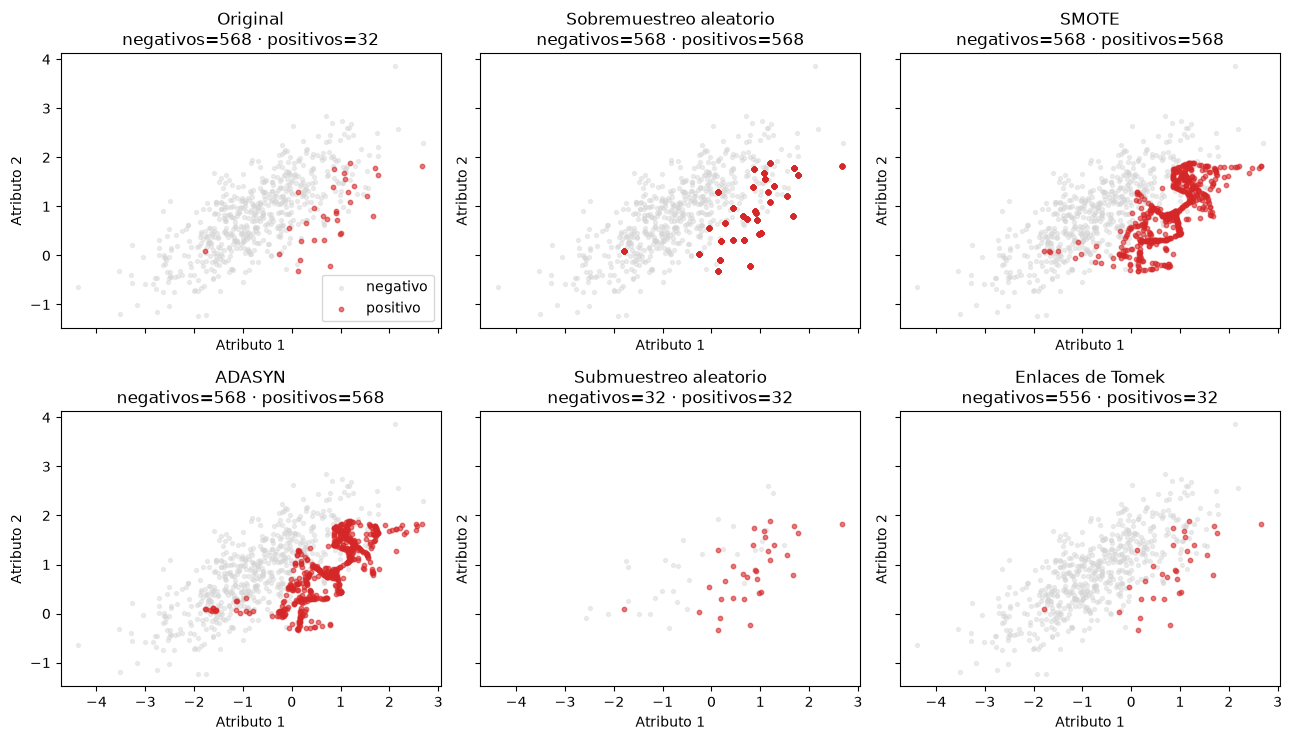

In [8]:
X_2d, y_2d = make_classification(
    n_samples=600, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, weights=[0.95], class_sep=0.8, random_state=42)

tecnicas = {
    "Original": None,
    "Sobremuestreo aleatorio": RandomOverSampler(random_state=42),
    "SMOTE": SMOTE(random_state=42),
    "ADASYN": ADASYN(random_state=42),
    "Submuestreo aleatorio": RandomUnderSampler(random_state=42),
    "Enlaces de Tomek": TomekLinks(),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True, sharey=True)
for ax, (nombre, tecnica) in zip(axes.ravel(), tecnicas.items()):
    Xr, yr = (X_2d, y_2d) if tecnica is None else tecnica.fit_resample(X_2d, y_2d)
    ax.scatter(Xr[yr == 0, 0], Xr[yr == 0, 1], s=8, alpha=0.4, c="lightgray", label="negativo")
    ax.scatter(Xr[yr == 1, 0], Xr[yr == 1, 1], s=10, alpha=0.6, c="tab:red", label="positivo")
    ax.set_title(f"{nombre}\nnegativos={np.sum(yr == 0)} · positivos={np.sum(yr == 1)}")
    ax.set_xlabel("Atributo 1")
    ax.set_ylabel("Atributo 2")
axes[0, 0].legend(loc="lower right")
plt.tight_layout()
plt.show()

- El **sobremuestreo aleatorio** llega a 568 positivos (tantos como negativos), pero el gráfico parece igual que el original: los puntos nuevos son **copias exactas** superpuestas.
- **SMOTE** rellena los segmentos entre positivos vecinos: aparecen puntos nuevos entre los originales.
- **ADASYN** concentra los puntos sintéticos en las zonas donde los positivos se mezclan con los negativos.
- El **submuestreo aleatorio** deja solo 32 negativos: se pierde la mayor parte de la información de la clase mayoritaria.
- Los **enlaces de Tomek** eliminan solo 12 negativos, todos en la frontera. No equilibran las clases; limpian.

### 3.6. Comparación de técnicas con validación cruzada

El remuestreo debe aplicarse **solo a las particiones de entrenamiento** de cada iteración, nunca a la de validación. El `Pipeline` de `imblearn` (no el de scikit-learn) lo hace automáticamente: remuestrea en `fit` y no toca los datos en `predict`.

In [9]:
def regresion(**kwargs):
    return LogisticRegression(max_iter=1000, **kwargs)

modelos = {
    "Sin tratar": make_pipeline(StandardScaler(), regresion()),
    "Pesos de clase": make_pipeline(StandardScaler(), regresion(class_weight="balanced")),
    "Sobremuestreo aleatorio": make_pipeline(StandardScaler(), RandomOverSampler(random_state=42), regresion()),
    "SMOTE": make_pipeline(StandardScaler(), SMOTE(random_state=42), regresion()),
    "ADASYN": make_pipeline(StandardScaler(), ADASYN(random_state=42), regresion()),
    "Submuestreo aleatorio": make_pipeline(StandardScaler(), RandomUnderSampler(random_state=42), regresion()),
    "Enlaces de Tomek": make_pipeline(StandardScaler(), TomekLinks(), regresion()),
    "Random forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Balanced random forest": BalancedRandomForestClassifier(
        n_estimators=200, sampling_strategy="all", replacement=True, bootstrap=False,
        random_state=42, n_jobs=-1),
}

metricas = ["accuracy", "precision", "recall", "f1", "average_precision", "roc_auc"]
filas = []
for nombre, modelo in modelos.items():
    res = cross_validate(modelo, X_train, y_train, cv=cv, scoring=metricas)
    filas.append({"modelo": nombre, **{m: res[f"test_{m}"].mean() for m in metricas}})

comparacion = pd.DataFrame(filas).set_index("modelo").round(3)
comparacion

,accuracy,precision,recall,f1,average_precision,roc_auc
modelo,,,,,,
Sin tratar,0.984,0.826,0.405,0.527,0.615,0.905
Pesos de clase,0.892,0.156,0.821,0.262,0.517,0.917
Sobremuestreo aleatorio,0.893,0.157,0.821,0.263,0.515,0.916
SMOTE,0.895,0.159,0.815,0.266,0.501,0.919
ADASYN,0.821,0.105,0.882,0.187,0.417,0.919
Submuestreo aleatorio,0.882,0.149,0.831,0.251,0.455,0.915
Enlaces de Tomek,0.984,0.812,0.431,0.549,0.610,0.906
Random forest,0.987,0.897,0.528,0.654,0.736,0.938
Balanced random forest,0.948,0.288,0.836,0.428,0.677,0.955


Los resultados muestran el patrón típico:

- **Todas las técnicas de rebalanceo** (pesos de clase, sobremuestreo, SMOTE, ADASYN, submuestreo) suben mucho el **recall**, de ~0,40 a más de 0,8, pero **hunden la precisión**, de ~0,83 a ~0,1–0,16. Detectan casi todas las microcalcificaciones a costa de muchísimas falsas alarmas, y su $F_1$ baja.
- La **precisión media** (PR-AUC), que no depende del umbral, **no mejora** con ninguna de ellas. En este caso, rebalancear no ha enseñado al modelo nada nuevo: sobre todo ha desplazado su punto de decisión.
- La **ROC-AUC** ronda 0,9 en todos los modelos lineales, incluido el que apenas detecta el 40 % de los positivos. Con desbalanceo fuerte es demasiado optimista.
- **Pesos de clase** y **sobremuestreo aleatorio** dan resultados prácticamente idénticos, como anticipaba la teoría: dar a cada error minoritario el peso de muchas copias equivale a crear esas copias.
- Los **enlaces de Tomek** apenas cambian nada, porque solo limpian la frontera.
- Los modelos de **bosque aleatorio** capturan relaciones no lineales y tienen la precisión media más alta. La versión balanceada vuelve a cambiar precisión por recall.

¿Qué técnica elegir? Depende del **coste de cada error**. En un cribado médico, un falso negativo (una calcificación no detectada) cuesta mucho más que una falsa alarma, y un recall alto es lo prioritario. Pero esa decisión se toma mejor de forma explícita, eligiendo el umbral.

### 3.7. Ajuste del umbral de decisión

`TunedThresholdClassifierCV` busca, con validación cruzada interna, el umbral que maximiza una métrica (aquí $F_1$). Lo comparamos en el conjunto de prueba con el modelo sin tratar (umbral 0,5) y con SMOTE:

In [10]:
base = make_pipeline(StandardScaler(), regresion()).fit(X_train, y_train)
con_smote = make_pipeline(StandardScaler(), SMOTE(random_state=42), regresion()).fit(X_train, y_train)
ajustado = TunedThresholdClassifierCV(
    make_pipeline(StandardScaler(), regresion()), scoring="f1", cv=cv).fit(X_train, y_train)

filas = []
for nombre, modelo in [("Umbral 0,5", base), ("SMOTE (umbral 0,5)", con_smote),
                       (f"Umbral ajustado ({ajustado.best_threshold_:.2f})".replace(".", ","), ajustado)]:
    pred = modelo.predict(X_test)
    filas.append({"modelo": nombre, "precisión": precision_score(y_test, pred),
                  "recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred)})
pd.DataFrame(filas).set_index("modelo").round(3)

,precisión,recall,F1
modelo,,,
"Umbral 0,5",0.750,0.369,0.495
"SMOTE (umbral 0,5)",0.187,0.908,0.310
"Umbral ajustado (0,26)",0.625,0.538,0.579


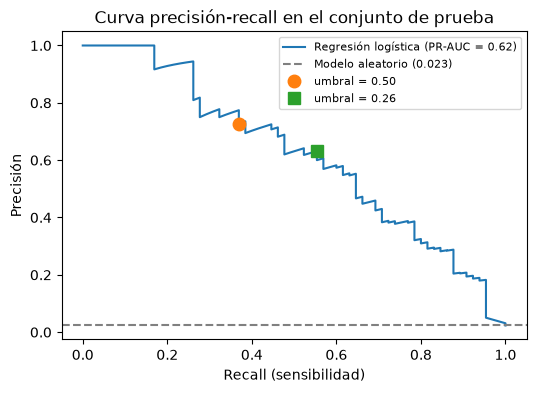

In [11]:
prob = base.predict_proba(X_test)[:, 1]
precision, recall, umbrales = precision_recall_curve(y_test, prob)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall, precision, label=f"Regresión logística (PR-AUC = {average_precision_score(y_test, prob):.2f})")
ax.axhline(y_test.mean(), color="gray", linestyle="--", label=f"Modelo aleatorio ({y_test.mean():.3f})")
for umbral, marca in [(0.5, "o"), (ajustado.best_threshold_, "s")]:
    i = np.argmin(np.abs(umbrales - umbral))
    ax.plot(recall[i], precision[i], marca, markersize=9, label=f"umbral = {umbral:.2f}")
ax.set_xlabel("Recall (sensibilidad)")
ax.set_ylabel("Precisión")
ax.set_title("Curva precisión-recall en el conjunto de prueba")
ax.legend(loc="upper right", fontsize=8)
plt.show()

Cada punto de la curva es un umbral posible. El umbral por defecto (0,5) queda en una zona de precisión alta y recall bajo. Bajarlo desplaza el punto hacia la derecha: más recall a cambio de algo de precisión. El umbral ajustado mejora el $F_1$ en el conjunto de prueba sin generar ningún dato sintético. Si el coste de los errores es asimétrico, se puede optimizar otra métrica, como el recall con una precisión mínima, o una función de coste.

Para ver el detalle por clase, `classification_report` da precisión, recall y $F_1$ de cada clase, más los promedios macro y ponderado:

In [12]:
print(classification_report(y_test, ajustado.predict(X_test),
                            target_names=["normal", "microcalcificación"], digits=3))

                    precision    recall  f1-score   support

            normal      0.989     0.992     0.991      2731
microcalcificación      0.625     0.538     0.579        65

          accuracy                          0.982      2796
         macro avg      0.807     0.765     0.785      2796
      weighted avg      0.981     0.982     0.981      2796



## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Clase / función | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `train_test_split` | `stratify` | Mantener la proporción de clases | `stratify=y` **siempre** en clasificación |
| `DataFrame.sample` | `replace`, `frac`, `weights` | Muestreo con o sin reemplazamiento, tamaño y probabilidades de selección | `replace=True` para bootstrap; `weights` para muestrear con probabilidades distintas |
| `StratifiedKFold` | `n_splits`, `shuffle` | Particiones estratificadas de la validación cruzada | Cada partición debe tener suficientes positivos; baja `n_splits` si hay muy pocos |
| Remuestreadores de `imblearn` | `sampling_strategy` | Proporción objetivo tras remuestrear | `"auto"` iguala las clases. Un número (p. ej. `0.3`) deja un desbalanceo más suave |
| `SMOTE`, `ADASYN` | `k_neighbors` / `n_neighbors` | Vecinos para interpolar | 5 por defecto. Con muy pocos positivos, valores menores |
| `SMOTENC` | `categorical_features` | Qué columnas son categóricas | Úsalo en lugar de SMOTE si hay categóricas |
| Modelos de scikit-learn | `class_weight` | Peso de los errores de cada clase | `"balanced"` o un diccionario con pesos propios |
| `TunedThresholdClassifierCV` | `scoring` | Métrica que se optimiza al elegir el umbral | `"f1"`, `"balanced_accuracy"` o una métrica de coste propia |
| Métricas | `average` | Cómo se combinan las clases | `"macro"` para que cada clase cuente igual |

### 4.2. Errores comunes

Varias de estas lecciones salen de un análisis real de accidentes de tráfico. La gravedad (sin víctimas, heridos leves, heridos graves, fallecidos) estaba muy desbalanceada: los accidentes mortales eran solo **25 de 12.500** (0,2 %) tras cruzar las fuentes.

**1. Dividir sin estratificar con una clase rarísima.** Con `train_test_split(..., shuffle=True)` sin `stratify`, el número de accidentes mortales en el conjunto de prueba (30 %) variaba entre **7 y 14** según la semilla. En el peor caso quedaban solo **11** para entrenar. Con clases tan raras, `stratify=y` no es opcional (ver 3.2).

**2. Igualar las clases a toda costa.** Sobremuestrear hasta que las cuatro clases tuvieran el mismo tamaño (7.514 casos cada una) obligó al sobremuestreo aleatorio a **copiar cada accidente mortal unas 442 veces**. Un modelo flexible acaba memorizando esos 17 casos. Usa `sampling_strategy` para un equilibrio parcial, prefiere pesos de clase o ajuste del umbral, y valora si la clase es tan rara que es mejor agruparla con otra (por ejemplo, "grave o mortal").

**3. Remuestrear fuera de la validación cruzada.** Aplicar SMOTE a todo el entrenamiento y **después** hacer validación cruzada hace que las particiones de validación contengan puntos sintéticos creados a partir de las de entrenamiento: el modelo se evalúa con variaciones de datos que ya ha visto. El remuestreo en el conjunto de entrenamiento se hizo bien en ese análisis (solo en entrenamiento, nunca en prueba), pero dentro de una validación cruzada hay que usar el `Pipeline` de `imblearn`:

In [13]:
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier())

fuera = cross_val_score(knn, X_sm, y_sm, cv=cv, scoring="f1").mean()
dentro = cross_val_score(make_pipeline(StandardScaler(), SMOTE(random_state=42), KNeighborsClassifier()),
                         X_train, y_train, cv=cv, scoring="f1").mean()
real = f1_score(y_test, make_pipeline(StandardScaler(), SMOTE(random_state=42), KNeighborsClassifier())
                .fit(X_train, y_train).predict(X_test))

print(f"F1 en CV con SMOTE antes de la CV:   {fuera:.3f}")
print(f"F1 en CV con SMOTE dentro del pipeline: {dentro:.3f}")
print(f"F1 real en el conjunto de prueba:      {real:.3f}")

F1 en CV con SMOTE antes de la CV:   0.966
F1 en CV con SMOTE dentro del pipeline: 0.452
F1 real en el conjunto de prueba:      0.474


La validación cruzada "contaminada" promete un $F_1$ muy superior al que el modelo consigue después con datos nuevos. La del pipeline se acerca mucho más a la realidad. (Además, la validación contaminada tiene un 50 % de positivos, así que mide otro problema.)

**4. SMOTE con variables categóricas codificadas.** SMOTE interpola, y entre `color_rojo = 0` y `color_rojo = 1` genera valores como 0,37, que no corresponden a ninguna categoría. `SMOTENC` interpola las numéricas y asigna a las categóricas el valor más frecuente entre los vecinos:

In [14]:
rng = np.random.default_rng(42)
ejemplo = pd.DataFrame({
    "tamano": rng.normal(10, 2, 60).round(1),
    "color": rng.choice(["rojo", "azul", "verde"], 60),
})
y_ej = np.r_[np.zeros(50), np.ones(10)].astype(int)

# SMOTE sobre la versión one-hot: categorías "fraccionarias"
onehot = pd.get_dummies(ejemplo, columns=["color"], dtype=float)
X_s, _ = SMOTE(random_state=42).fit_resample(onehot, y_ej)
print("SMOTE (one-hot):")
print(X_s.iloc[60:63].round(2).to_string())

# SMOTENC: la categoría sigue siendo una categoría
X_nc, _ = SMOTENC(categorical_features=["color"], random_state=42).fit_resample(ejemplo, y_ej)
print("\nSMOTENC:")
print(X_nc.iloc[60:63].round(2).to_string())

SMOTE (one-hot):
    tamano  color_azul  color_rojo  color_verde
60   12.39        0.00        1.00         0.00
61    8.75        0.93        0.00         0.07
62    9.28        0.00        0.95         0.05

SMOTENC:
    tamano  color
60   12.39  verde
61    8.75  verde
62    9.28  verde


**5. Evaluar con exactitud (o solo con ROC-AUC).** Con un 2,3 % de positivos, el clasificador trivial tiene un 97,7 % de exactitud (3.4), y un modelo que solo detecta el 40 % de los positivos tiene una ROC-AUC de 0,9 (3.6). Informa de la precisión, el recall y el $F_1$ **de la clase minoritaria**, o del $F_1$ macro, y usa la PR-AUC para comparar modelos. En un problema de clasificación de estados de turbinas con desbalanceo moderado se eligió el $F_1$ macro por este motivo: cada clase cuenta igual, y la mayoritaria ("funcionamiento normal") no domina la métrica.

**6. Pensar que rebalancear siempre mejora el modelo.** En 3.6, ninguna técnica de remuestreo mejoró la precisión media: sobre todo movieron el umbral de decisión. Antes de generar datos sintéticos, prueba a **ajustar el umbral** (3.7) o a usar **pesos de clase**, que son más simples y no alteran los datos. Remuestrear tiene sentido cuando el modelo realmente aprende mejor con más ejemplos minoritarios, y eso hay que comprobarlo con validación cruzada.

## 5. Comparación con métodos relacionados

| Técnica | Nivel | Qué hace | Ventajas | Inconvenientes |
|---|---|---|---|---|
| Partición estratificada | Evaluación | Mantiene la proporción de clases en cada conjunto | Evaluación estable; siempre recomendable | Ninguno relevante |
| Sobremuestreo aleatorio | Datos | Duplica minoritarios | Simple; no pierde información | Copias exactas → sobreajuste |
| SMOTE | Datos | Interpola minoritarios vecinos | Ejemplos nuevos, no copias | Puede crear puntos en zonas de la otra clase; no apto para categóricas (usar SMOTENC) |
| ADASYN | Datos | SMOTE centrado en la frontera | Refuerza las zonas difíciles | Amplifica el ruido de la frontera |
| Submuestreo aleatorio | Datos | Descarta mayoritarios | Rápido; datasets más pequeños | Pierde información |
| Enlaces de Tomek / ENN | Datos | Limpia la frontera | Fronteras más claras | No equilibra las clases |
| Pesos de clase | Modelo | Penaliza más los errores minoritarios | Sin datos nuevos; un solo parámetro | No todos los modelos lo admiten |
| Balanced random forest | Modelo | Cada árbol ve una muestra balanceada | Usa todos los datos en el conjunto del bosque | Más costoso; sigue desplazando precisión hacia recall |
| Ajuste del umbral | Decisión | Elige el punto de corte según una métrica | No altera datos ni modelo; decisión explícita según el coste | Necesita probabilidades bien ordenadas y validación para elegirlo |

**Orden práctico:** partición estratificada y métrica adecuada → modelo base → pesos de clase o ajuste del umbral → remuestreo solo si la validación cruzada muestra que aporta.

## 6. Referencias

### Fuentes

- imbalanced-learn: [*User guide*](https://imbalanced-learn.org/stable/user_guide.html) (sobremuestreo, submuestreo, `BalancedRandomForestClassifier` y `Pipeline`).
- scikit-learn: [*Tuning the decision threshold for class prediction*](https://scikit-learn.org/stable/modules/classification_threshold.html), [*Cross-validation*](https://scikit-learn.org/stable/modules/cross_validation.html) (particiones estratificadas) y [*Metrics and scoring*](https://scikit-learn.org/stable/modules/model_evaluation.html) (precisión, recall, $F_1$, precisión media).
- Dataset: [*mammography*, OpenML id 310](https://www.openml.org/d/310). Origen: Woods, K. et al. (1993), estudio sobre la detección de microcalcificaciones en mamografías.

### Para saber más

- Chawla, N. V., Bowyer, K. W., Hall, L. O. y Kegelmeyer, W. P. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research, 16, 321–357. El artículo original de SMOTE.
- He, H. y Garcia, E. A. (2009). *Learning from Imbalanced Data*. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284. Revisión clásica de técnicas y métricas para datos desbalanceados.